# Overview {#sec-conceptnet}

Our second hypothesis tests the effect of degree of misunderstanding on the magnitude of effort. 

We operationalize degree of misunderstanding as a conceptual similarity between target concept and answer offered by a guesser. 

To have a reproducible measure of conceptual similarity, we use the ConceptNet [@speer_etal18] to extract embeddings for concepts used in our study, and calculate cosine similarity between the target concept and guessed answer. 

To verify the utility of the cosine similarity, we have collected data from 14 Dutch-native people who were asked to rate the similarity between each pair of words in online anonymous rating study. We then compared the 'perceived similarity' with cosine similarity computed from ConceptNet embeddings, to validate the use of ConceptNet embeddings as a measure of conceptual similarity. This analysis is available in the [preregistered script](https://github.com/sarkadava/FLESH_Effort/blob/preregistered/06_ConceptSimilarity/ConceptNet_similarity.ipynb){target="_blank"}.

In [ ]:
#| code-fold: true
#| code-summary: Code to load packages and prepare environment

import numpy as np
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl
from math import nan

curfolder = os.getcwd()
rawdata = os.path.join(curfolder, '..', '00_raw')
answerfiles = glob.glob(os.path.join(rawdata, '*', '*results_part2.csv'), recursive=True)
datafolder = os.path.join(curfolder, 'data')

# Loop over list and add it into one big df
df_all = pd.DataFrame()
for file in answerfiles:
    df = pd.read_csv(file)
    # create column trial_order which will be the index/row number
    df['trial_order'] = df.index
    df_all = pd.concat([df_all, df], ignore_index=True)

df_all['exp'] = 2

# Keep only columns word and answer
df = df_all[['ID', 'trial_order', 'word', 'answer', 'exp']]
df.head(20)

,ID,trial_order,word,answer,exp
0,10,0,zwaaien,zwaaien,2
1,10,1,juichen,dansen,2
2,10,2,juichen,juichen,2
3,10,3,vis,vis,2
4,10,4,hoog,groot,2
5,10,5,hoog,rijken,2
6,10,6,hoog,hoog,2
7,10,7,regen,regen,2
8,10,8,verdrietig,huilen,2
9,10,9,verdrietig,verdrietig,2


First we need to do some data-wrangling to get all in the right format for the embedding extraction and comparison


In [74]:
#| eval: false

# concept list
df_concepts = pd.read_excel(os.path.join(rawdata, 'conceptlist_info.xlsx'))

# in df_concepts, keep only English and Dutch
df_concepts = df_concepts[['English', 'Dutch']]

# rename Dutch to word
df_concepts = df_concepts.rename(columns={'Dutch': 'word'})

# merge df and df_concepts on word
df = pd.merge(df, df_concepts, on='word', how='left')

# show rows where English is NaN
df[df['English'].isnull()]

# add translations manually for each (these are practice trials)
df.loc[df['word'] == 'bloem', 'English'] = 'flower'
df.loc[df['word'] == 'dansen', 'English'] = 'to dance'
df.loc[df['word'] == 'auto', 'English'] = 'car'
df.loc[df['word'] == 'olifant', 'English'] = 'elephant'
df.loc[df['word'] == 'comfortabel', 'English'] = 'comfortable'
df.loc[df['word'] == 'bal', 'English'] = 'ball'
df.loc[df['word'] == 'haasten', 'English'] = 'to hurry'
df.loc[df['word'] == 'gek', 'English'] = 'crazy'
df.loc[df['word'] == 'snijden', 'English'] = 'to cut'
df.loc[df['word'] == 'koken', 'English'] = 'to cook'
df.loc[df['word'] == 'juichen', 'English'] = 'to cheer'
df.loc[df['word'] == 'zingen', 'English'] = 'to sing'
df.loc[df['word'] == 'glimlach', 'English'] = 'smile'
df.loc[df['word'] == 'klok', 'English'] = 'clock'
df.loc[df['word'] == 'fiets', 'English'] = 'bicycle'
df.loc[df['word'] == 'vliegtuig', 'English'] = 'airplane'
df.loc[df['word'] == 'geheim', 'English'] = 'secret'
df.loc[df['word'] == 'telefoon', 'English'] = 'telephone'
df.loc[df['word'] == 'zwaaien', 'English'] = 'to wave'
df.loc[df['word'] == 'sneeuw', 'English'] = 'snow'
df.loc[df['word'] == 'rijk', 'English'] = 'rich'
df.loc[df['word'] == 'leeg', 'English'] = 'empty'
df.loc[df['word'] == 'hond', 'English'] = 'dog'
df.loc[df['word'] == 'knippen', 'English'] = 'to cut'
df.loc[df['word'] == 'eend', 'English'] = 'duck'

# get rid of English 'to beat'
df_final = df[df['English'] != 'to beat']
# and to weep
df_final = df[df['English'] != 'to weep']
# and noisy
df_final = df[df['English'] != 'noisy']

# keep only rows where word is not NaN
df = df[df['word'].notnull()]

# save it
df.to_csv(os.path.join(datafolder, 'concept_answer_withoutcossim.csv'), index=False)

df.head(20)

,ID,trial_order,word,answer,exp,English
0,10,0,zwaaien,zwaaien,2,to wave
1,10,1,juichen,dansen,2,to cheer
2,10,2,juichen,juichen,2,to cheer
3,10,3,vis,vis,2,fish
4,10,4,hoog,groot,2,high
5,10,5,hoog,rijken,2,high
6,10,6,hoog,hoog,2,high
7,10,7,regen,regen,2,rain
8,10,8,verdrietig,huilen,2,sad
9,10,9,verdrietig,verdrietig,2,sad


This is how the dataframe looks like

In [75]:
#| echo: false

# load in
df = pd.read_csv(os.path.join(datafolder, 'concept_answer_withoutcossim.csv'))

# display
df.head(15)

,ID,trial_order,word,answer,exp,English
0,10,0,zwaaien,zwaaien,2,to wave
1,10,1,juichen,dansen,2,to cheer
2,10,2,juichen,juichen,2,to cheer
3,10,3,vis,vis,2,fish
4,10,4,hoog,groot,2,high
5,10,5,hoog,rijken,2,high
6,10,6,hoog,hoog,2,high
7,10,7,regen,regen,2,rain
8,10,8,verdrietig,huilen,2,sad
9,10,9,verdrietig,verdrietig,2,sad


Now we need to correct answers because they contain typos

In [ ]:
# in answer, replace langaam by langzaam
df['answer'] = df['answer'].str.replace('langaam', 'langzaam')
df['answer'] = df['answer'].str.replace('langsaam', 'langzaam')
df['answer'] = df['answer'].str.replace('comfortable', 'comfortabel')
df['answer'] = df['answer'].str.replace('neurien', 'neuriën')
df['answer'] = df['answer'].str.replace('neurieen', 'neuriën')
df['answer'] = df['answer'].str.replace('verdietig', 'verdrietig')
df['answer'] = df['answer'].str.replace('skien', 'skiën')
df['answer'] = df['answer'].str.replace('skieen', 'skiën')
df['answer'] = df['answer'].str.replace('geirriteerd', 'geïrriteerd')
df['answer'] = df['answer'].str.replace('vliegtug', 'vliegtuig')
df['answer'] = df['answer'].str.replace('basketba', 'basketbal')
df['answer'] = df['answer'].str.replace('basketball', 'basketbal')
df['answer'] = df['answer'].str.replace('geirriteerd', 'geïrriteerd')
df['answer'] = df['answer'].str.replace('shift', '')
df['answer'] = df['answer'].str.replace('svhieten', 'schieten', regex=False)
df['answer'] = df['answer'].str.replace('scrheeuwen', 'schreeuwen', regex=False)
df['answer'] = df['answer'].str.replace('neerkomem', 'neerkomen', regex=False)
df['answer'] = df['answer'].str.replace('watet', 'water', regex=False)
df['answer'] = df['answer'].str.replace('mastuberen', 'masturberen', regex=False)
df['answer'] = df['answer'].str.replace('shrikken', 'schrikken', regex=False)
df['answer'] = df['answer'].str.replace('grafiti', 'graffiti', regex=False)
df['answer'] = df['answer'].str.replace('vliegtuid', 'vliegtuig', regex=False)
df['answer'] = df['answer'].str.replace('grinikken', 'grinniken', regex=False)
df['answer'] = df['answer'].str.replace('nurien', 'neuriën', regex=False)
df['answer'] = df['answer'].str.replace('optijd', 'op tijd', regex=False)
df['answer'] = df['answer'].str.replace('ontwetend', 'onwetend', regex=False)
df['answer'] = df['answer'].str.replace('verluisteren', 'fluisteren', regex=False)
df['answer'] = df['answer'].str.replace('luchtballin', 'luchtballon', regex=False)
df['answer'] = df['answer'].str.replace('omhooh', 'omhoog', regex=False)
df['answer'] = df['answer'].str.replace('rodellen', 'roddelen', regex=False)
df['answer'] = df['answer'].str.replace('snappem', 'snappen', regex=False)
df['answer'] = df['answer'].str.replace('indrukwekkebd', 'indrukwekkend', regex=False)
df['answer'] = df['answer'].str.replace('zwaairn', 'zwaaien', regex=False)
df['answer'] = df['answer'].str.replace('heigen', 'hijgen', regex=False)
df['answer'] = df['answer'].str.replace('gestressd', 'gestrest', regex=False)
df['answer'] = df['answer'].str.replace('kouwen', 'kauwen', regex=False)
df['answer'] = df['answer'].str.replace('shouders', 'schouders', regex=False)
df['answer'] = df['answer'].str.replace('ballom', 'ballon', regex=False)
df['answer'] = df['answer'].str.replace('autocoereur', 'autocoureur', regex=False)
df['answer'] = df['answer'].str.replace('lachrn', 'lachen', regex=False)
df['answer'] = df['answer'].str.replace('fitesen', 'fietsen', regex=False)
df['answer'] = df['answer'].str.replace('scieten', 'schieten', regex=False)
df['answer'] = df['answer'].str.replace('stamoen', 'stamperen', regex=False)
df['answer'] = df['answer'].str.replace('blixem', 'bliksem', regex=False)
df['answer'] = df['answer'].str.replace('proefen', 'proeven', regex=False)
df['answer'] = df['answer'].str.replace('blokfuit', 'blokfluit', regex=False)
df['answer'] = df['answer'].str.replace('verdrietig ', 'verdrietig', regex=False)
df['answer'] = df['answer'].str.replace('galloperen', 'galopperen', regex=False)
df['answer'] = df['answer'].str.replace('leegl', 'leeg', regex=False)
df['answer'] = df['answer'].str.replace('kinker', 'klinker', regex=False)
df['answer'] = df['answer'].str.replace('gehiem', 'geheim', regex=False)
df['answer'] = df['answer'].str.replace('voge', 'vogel', regex=False)
df['answer'] = df['answer'].str.replace('vogell', 'vogel', regex=False)
df['answer'] = df['answer'].str.replace('grinnikken', 'grinniken', regex=False)
df['answer'] = df['answer'].str.replace('drinken ', 'drinken', regex=False)
df['answer'] = df['answer'].str.replace('gieberen', 'gibberen', regex=False)
df['answer'] = df['answer'].str.replace('juichenl', 'juichen', regex=False)
df['answer'] = df['answer'].str.replace('juigen', 'juichen', regex=False)
df['answer'] = df['answer'].str.replace('backlash', '', regex=False)
df['answer'] = df['answer'].str.replace('backslash', '', regex=False)
df['answer'] = df['answer'].str.replace('vlief', 'vlieg', regex=False)
df['answer'] = df['answer'].str.replace('leegopen', 'leeglopen', regex=False)
df['answer'] = df['answer'].str.replace('sprinkelen', 'sprenkelen', regex=False)
df['answer'] = df['answer'].str.replace('fohn', 'föhn', regex=False) 
df['answer'] = df['answer'].str.replace('busstop', 'bushalte', regex=False)
df['answer'] = df['answer'].str.replace('buitenadem', 'buiten adem', regex=False)
df['answer'] = df['answer'].str.replace('slowmoting', 'slowmotion', regex=False)
df['answer'] = df['answer'].str.replace('olifcapslockn', 'olifant', regex=False)
df['answer'] = df['answer'].str.replace('ski vakante', 'skivakantie', regex=False)
df['answer'] = df['answer'].str.replace('verbeisterd', 'verbijsterd', regex=False)
df['answer'] = df['answer'].str.replace('fles ontpoppen', 'fles ontkurken', regex=False)
df['answer'] = df['answer'].str.replace('margeren', 'marcheren', regex=False)
df['answer'] = df['answer'].str.replace('knock out', 'knockout', regex=False)
df['answer'] = df['answer'].str.replace('knarzen', 'knarsen', regex=False)
df['answer'] = df['answer'].str.replace('ping pong', 'pingpong', regex=False)
df['answer'] = df['answer'].str.replace('typgeluid', 'typegeluid', regex=False)
df['answer'] = df['answer'].str.replace('typgeluid', 'typegeluid', regex=False)
df['answer'] = df['answer'].str.replace('oorkest', 'orkest', regex=False)
df['answer'] = df['answer'].str.replace('ruizen', 'ruisen', regex=False)
df['answer'] = df['answer'].str.replace('skydiving', 'skydiven', regex=False)
df['answer'] = df['answer'].str.replace('lslash', '', regex=False)
df['answer'] = df['answer'].str.replace('auto rijden', 'autorijden', regex=False)
df['answer'] = df['answer'].str.replace('disgust', 'walging', regex=False)
df['answer'] = df['answer'].str.replace('elektrisiteit', 'elektriciteit', regex=False)
df['answer'] = df['answer'].str.replace('sleeen', 'sleeën', regex=False)
df['answer'] = df['answer'].str.replace('reaching', 'reiken', regex=False)
df['answer'] = df['answer'].str.replace('skippiebal', 'skippybal', regex=False)
df['answer'] = df['answer'].str.replace('kokhalsen', 'kokhalzen', regex=False)
df['answer'] = df['answer'].str.replace('grinnik', 'grinniken', regex=False)
df['answer'] = df['answer'].str.replace('pinguin', 'pinguïn', regex=False)
df['answer'] = df['answer'].str.replace('discodisco', 'disco', regex=False)
df['answer'] = df['answer'].str.replace('oudpersoon', 'oud persoon', regex=False)
df['answer'] = df['answer'].str.replace('griniken', 'grinniken', regex=False)
df['answer'] = df['answer'].str.replace('ping pongen', 'pingpongen', regex=False)
df['answer'] = df['answer'].str.replace('boederij', 'boerderij', regex=False)
df['answer'] = df['answer'].str.replace('paardijden', 'paardrijden', regex=False)
df['answer'] = df['answer'].str.replace('neuril', '', regex=False)
df['answer'] = df['answer'].str.replace('f1', 'formula 1', regex=False)
df['answer'] = df['answer'].str.replace('stamperen', 'stampen', regex=False)
df['answer'] = df['answer'].str.replace('stilzijn', 'stil zijn', regex=False)
df['answer'] = df['answer'].str.replace('bbq', 'barbecue', regex=False)
df['answer'] = df['answer'].str.replace('zur', 'zuur', regex=False)
df['answer'] = df['answer'].str.replace('hgvlgi', '', regex=False)
df['answer'] = df['answer'].str.replace('awkward', 'ongemakkelijk', regex=False)
df['answer'] = df['answer'].str.replace('typem', 'typen', regex=False)
df['answer'] = df['answer'].str.replace('goedzo', 'goed zo', regex=False)
df['answer'] = df['answer'].str.replace('chirpen', 'tjirpen', regex=False)
df['answer'] = df['answer'].str.replace('onwetenheid', 'onwetendheid', regex=False)
df['answer'] = df['answer'].str.replace('verweg', 'ver weg', regex=False)
df['answer'] = df['answer'].str.replace('kotsem', 'kotsen', regex=False)
df['answer'] = df['answer'].str.replace('afgrijzing', 'afgrijzen', regex=False)
df['answer'] = df['answer'].str.replace('kostem', 'kotsen', regex=False)
df['answer'] = df['answer'].str.replace('boxen', 'boksen', regex=False)
df['answer'] = df['answer'].str.replace('blasen', 'blazen', regex=False)
df['answer'] = df['answer'].str.replace('telefooneren', 'telefoneren', regex=False)
df['answer'] = df['answer'].str.replace('motor rijden', 'motorrijden', regex=False)
df['answer'] = df['answer'].str.replace('ademenen', 'ademen', regex=False)
df['answer'] = df['answer'].str.replace('lrijden', 'rijden', regex=False)
df['answer'] = df['answer'].str.replace('pijlenboog', 'pijl-en-boog', regex=False)
df['answer'] = df['answer'].str.replace('giegelen', 'giechelen', regex=False)
df['answer'] = df['answer'].str.replace('nijdi', 'nijdig', regex=False)
df['answer'] = df['answer'].str.replace('banden oppompe', 'banden oppompen', regex=False)
df['answer'] = df['answer'].str.replace('giegelen', 'giechelen', regex=False)
df['answer'] = df['answer'].str.replace('iets pakken', 'pakken', regex=False)
df['answer'] = df['answer'].str.replace('iets geven', 'geven', regex=False)
df['answer'] = df['answer'].str.replace('grinnikenen', 'grinniken', regex=False)
df['answer'] = df['answer'].str.replace('grinneken', 'grinniken', regex=False)
df['answer'] = df['answer'].str.replace('over weging', 'over wegen', regex=False)
df['answer'] = df['answer'].str.replace('grinneken', 'grinniken', regex=False)
df['answer'] = df['answer'].str.replace('feluisteren', 'fluisteren', regex=False)
df['answer'] = df['answer'].str.replace('openhaart', 'open haard', regex=False)
df['answer'] = df['answer'].str.replace('silte vragen', 'stilte vragen', regex=False)
df['answer'] = df['answer'].str.replace('stewardes', 'stewardess', regex=False)
df['answer'] = df['answer'].str.replace('diamand', 'diamant', regex=False)
df['answer'] = df['answer'].str.replace('volzitten', 'vol zitten', regex=False)
df['answer'] = df['answer'].str.replace('bergklimmen', 'bergbeklimmen', regex=False)
df['answer'] = df['answer'].str.replace('uitgleiden', 'uitglijden', regex=False)
df['answer'] = df['answer'].str.replace('formula 1', 'formule 1', regex=False)
df['answer'] = df['answer'].str.replace('openhaard', 'open haard', regex=False)
df['answer'] = df['answer'].str.replace('over wegen', 'overwegen', regex=False)
df['answer'] = df['answer'].str.replace('doodslikken', 'doorslikken', regex=False)
df['answer'] = df['answer'].str.replace('kukkelen', 'kukelen', regex=False)
df['answer'] = df['answer'].str.replace('slow motion', 'slowmotion', regex=False)

# sometimes people directly answered they don't know 
df['answer'] = df['answer'].str.replace('geen idee', '', regex=False)
df['answer'] = df['answer'].str.replace('ik weet het niet', '', regex=False)
df['answer'] = df['answer'].str.replace('wtf', '', regex=False)

# if there is any string that has space in the beginning or the end, remove it
df['answer'] = df['answer'].str.strip()

# where word comfortabel and answer illen, change answer to chillen
df.loc[(df['word'] == 'comfortabel') & (df['answer'] == 'illen'), 'answer'] = 'chillen'

# where word is gek and answer llen, change answer to ''
df.loc[(df['word'] == 'gek') & (df['answer'] == 'llen'), 'answer'] = ''

In [78]:
# Sanity check: print rows that have any NA
df[df.isna().any(axis=1)]


,ID,trial_order,word,answer,exp,English
2894,35,75,klein,NaN,2,small
2898,35,79,kruipen,NaN,2,to crawl
4064,45,26,hoorn,NaN,2,horn
4526,49,43,telefoon,NaN,2,telephone
4527,49,44,zwaaien,NaN,2,to wave
7650,9,81,glimlach,NaN,2,smile


In these trials, the answer have been either not intelligible or just something like 'geen idee' or 'ik weet het niet'. Therefore we will put 0 cosine similarity for these trials.

# Calculating cosine similarity

Now we will load in [ConceptNet numberbatch (version 19.08)](https://github.com/commonsense/conceptnet-numberbatch){target="_blank"} and compute cosine similarity for each pair


In [ ]:
#| code-fold: true
#| code-summary: Custom functions

# Load embeddings from a file
def load_embeddings(file_path):
    """Load word embeddings from a text file where each line contains a word followed by its vector components.

    Args:
        file_path (str): Path to the file containing word embeddings.

    Returns:
        dict: A dictionary mapping words to their corresponding embedding vectors as numpy arrays.
    """
    embeddings = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

# Cosine similarity
def cosine_similarity(vec1, vec2):
    """Calculate the cosine similarity between two vectors.

    Args:
        vec1 (numpy.ndarray): First vector.
        vec2 (numpy.ndarray): Second vector.

    Returns:
        float: Cosine similarity between the two vectors.
    """
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

We will use multilingual numberbatch to extract words in the original language of experiment - Dutch. While English has better representation in ConceptNet, the English numberbatch does not make distinction between nouns and verbs (so 'a drink' and 'to drink' have common representation - drink). Because this is important distinction for us, we opt for Dutch embeddings to avoid this problem


In [10]:
# load embeddings
embeddings = load_embeddings(os.path.join('numberbatch', 'numberbatch.txt'))

This is how a single concept is represented (here skiën, engl. skiing)

In [80]:
#| echo: false

vec_nl = embeddings.get('/c/nl/skiën')
print(vec_nl)

[ 3.410e-02 -4.640e-02  5.490e-02  1.544e-01  1.800e-02 -5.050e-02
 -6.660e-02 -2.300e-02  5.320e-02  1.104e-01  2.770e-02  5.040e-02
 -2.010e-02  5.900e-03 -1.133e-01 -9.370e-02 -7.890e-02  3.540e-02
  3.780e-02  8.400e-02 -3.880e-02  7.680e-02 -8.010e-02  6.540e-02
 -1.493e-01 -1.036e-01  8.490e-02  1.040e-02 -6.890e-02  6.890e-02
  1.226e-01 -1.850e-02  1.520e-02  2.810e-02 -5.660e-02 -2.670e-02
 -5.700e-02 -4.480e-02  1.924e-01  5.800e-02 -7.800e-02 -7.700e-03
  1.132e-01  6.350e-02 -4.310e-02  1.900e-03 -4.820e-02  1.047e-01
  6.900e-02  7.150e-02  1.660e-02  2.730e-02  4.340e-02  1.130e-02
 -1.427e-01 -9.200e-03 -8.000e-04  2.310e-02  1.234e-01 -1.452e-01
 -1.710e-02 -1.094e-01 -1.518e-01  4.820e-02  1.400e-02 -1.460e-02
  1.023e-01  5.220e-02  1.362e-01  3.190e-02 -2.590e-02  1.220e-01
  1.750e-02  8.810e-02 -9.200e-02 -1.226e-01 -5.560e-02 -6.600e-03
  3.180e-02 -1.113e-01  6.130e-02 -1.202e-01 -2.480e-02 -8.300e-03
 -1.710e-02  3.410e-02  1.550e-02 -8.000e-02 -6.390e-02  1.170

Now we take the list of target-answer pairs, transform them into embedding format and perform cosine similarity.

In [ ]:
#| eval: false

# Dutch targets
meanings_nl = list(df['word'])
# Dutch answers
answers_nl = list(df['answer'])

word_embeddings_t = {}
for word in meanings_nl:
    #print(f"Processing word: {word}")
    word_embed = '/c/nl/' + word
    if word_embed in embeddings:
        word_embeddings_t[word] = embeddings[word_embed]

# get the embeddings for the words in the list answers_en
word_embeddings_ans = {}
for word in answers_nl:
    # if the word is not nan, process, if it's nan, just put nan embedding
    if pd.isna(word):
        word_embeddings_ans[word] = None
    else:
        word_embed = '/c/nl/' + word
        if word_embed in embeddings:
            word_embeddings_ans[word] = embeddings[word_embed]

# calculate the similarity between the first word in the list meanings_en and first word in answers_en, second word in meanings_en and second word in answers_en, etc.
cosine_similarities = []

for i in range(len(meanings_nl)):
    word1 = meanings_nl[i]
    word2 = answers_nl[i]

    vec1 = word_embeddings_t.get(word1)
    vec2 = word_embeddings_ans.get(word2)
    if vec1 is not None and vec2 is not None:
        cosine_sim = cosine_similarity(vec1, vec2)

        # if cosine similarity is negative, set it to 0.
        cosine_similarities.append(cosine_sim)
    else:
        # print which concepts could not be found
        if vec1 is None:
            print(f"Concept not found: {word1}")
            
        if vec2 is None:
            print(f"Concept not found: {word2}")
            # if the word is empty string or nan, put cosine_sim as 0
            if pd.isna(word2) or word2 == '':
                cosine_sim = 0
            else:
                cosine_sim = None
        
        cosine_similarities.append(cosine_sim)

df['cosine_similarity'] = cosine_similarities

Concept not found: slowmotion
Concept not found: catcallen
Concept not found: sniffen
Concept not found: bergwandeling
Concept not found: ver weg
Concept not found: 
Concept not found: wakker worden
Concept not found: ringtoon
Concept not found: moedergans
Concept not found: föhnen
Concept not found: vies eten
Concept not found: ver weg
Concept not found: kuikelen
Concept not found: highfive
Concept not found: kukelen
Concept not found: huh
Concept not found: ssst
Concept not found: startsignaal
Concept not found: ringtoon
Concept not found: fietsbel
Concept not found: oud en nieuw
Concept not found: open haard
Concept not found: 
Concept not found: zachtjes lopen
Concept not found: wc rol
Concept not found: stilte vragen
Concept not found: regendrank
Concept not found: hoge toon
Concept not found: vies eten
Concept not found: fietsbel
Concept not found: shotje
Concept not found: meteor
Concept not found: niet willen
Concept not found: hardcore
Concept not found: lekker vinden
Concept 

On the plot below, we can see the distribution of cosine similarity values. We see that very small portion of the values falls below zero. Negative cosine similarity usually indicates opposite meaning, but this is not case here, given that the largest negative value is -0.1 and most of the values are very close to 0. 


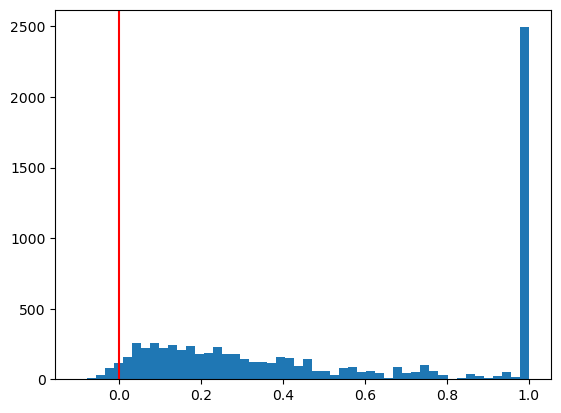

In [82]:
import matplotlib.pyplot as plt

vals = [c for c in cosine_similarities if c is not None]
plt.hist(vals, bins=50)
plt.axvline(0, color='red')
plt.show()

Instead of normalizing - which would distort the scale - we will set all negative cosine similarity values above 0 (to distinguish them from the 'no-idea' answers which we set to 0) and somewhere below the smallest positive cosine similarity.

In [ ]:
min_cosine = min([c for c in cosine_similarities if c is not None and c > 0])
print(f"Smallest positive cosine similarity: {min_cosine}")

Smallest positive cosine similarity: 0.00043843052117154


We will therefore set all negative cosine similarity values to 0.0001.
We will also set all values larger than 1 to 1, this is again non-meaningful distortion due to the embedding space.

In [ ]:
# set all negative cosine similarity values to 0.0001
for index, row in df.iterrows():
    if row['cosine_similarity'] is not None:
        if row['cosine_similarity'] < 0:
            df.at[index, 'cosine_similarity'] = 0.0001
        elif row['cosine_similarity'] > 1:
            df.at[index, 'cosine_similarity'] = 1.0

Just to be sure that we are not skewing the data, let's check descriptive of the original list and the df

In [85]:
mean_orig = np.mean([c for c in cosine_similarities if c is not None])
std_orig = np.std([c for c in cosine_similarities if c is not None])
median_orig = np.median([c for c in cosine_similarities if c is not None])

mean_new = df['cosine_similarity'].mean()
std_new = df['cosine_similarity'].std()
median_new = df['cosine_similarity'].median()

print(f"Original - Mean: {mean_orig}, Std: {std_orig}, Median: {median_orig}")
print(f"New - Mean: {mean_new}, Std: {std_new}, Median: {median_new}")


Original - Mean: 0.529121605897391, Std: 0.38258987750786466, Median: 0.4233475923538208
New - Mean: 0.5296676727170462, Std: 0.38182959338171735, Median: 0.4233475923538208


In [86]:
# Save it
df.to_csv(os.path.join(datafolder, 'conceptnet_clean.csv'), index=False)

This is how the resulting df looks like

In [87]:
#| echo: false

# load in the df
df = pd.read_csv(os.path.join(datafolder, 'conceptnet_clean.csv'))

# display
df.head(20)

,ID,trial_order,word,answer,exp,English,cosine_similarity
0,10,0,zwaaien,zwaaien,2,to wave,1.000000
1,10,1,juichen,dansen,2,to cheer,0.177888
2,10,2,juichen,juichen,2,to cheer,1.000000
3,10,3,vis,vis,2,fish,1.000000
4,10,4,hoog,groot,2,high,0.448479
5,10,5,hoog,rijken,2,high,0.233006
6,10,6,hoog,hoog,2,high,1.000000
7,10,7,regen,regen,2,rain,1.000000
8,10,8,verdrietig,huilen,2,sad,0.389033
9,10,9,verdrietig,verdrietig,2,sad,1.000000


When running the code, we will see that some target or answered concepts are not represented in numberbatch (e.g., if the answer has more than one word). 

Because we verified that cosine similarity and perceived similarity are highly correlated (see [preregistration](https://osf.io/8ajsg/overview){target="_blank"}), we collected the missing data through new online rating study.

# Adding data from perceived similarity

In [88]:
survey = pd.read_csv(os.path.join(datafolder, 'similarity_nl_responses_GForms.csv'), sep=',')

survey.head(15)

,Timestamp,langzaam - slowmotion,glimlach - catcallen,slaan - highfive,verdrietig - sniffen,berg - bergwandeling,ver - ver weg,ademen - buiten adem,oud - wakker worden,telefoon - ringtoon,...,telefoon - pakketbezorger,telefoon - tour de france,bitter - magnetronmaaltijd,staart - hondenshow,onweer - lightsaber,bloem - bloemen ruiken,goed - duim omhoog,bliksem - appels plukken,niet - niet goed,"If there were words you were not sure what they refer to, please note them down here"
0,11/12/2024 14:22:20,8,0,1,2,2,9,3,0,6,...,1,0,0,1,4,6,9,0,2,"griezelen, catcallen, kukkelen, tongzuur, klin..."
1,11/12/2024 15:41:15,9,5,6,7,8,9,8,2,7,...,2,7,3,4,3,8,8,2,7,chippen
2,12/12/2024 14:16:50,8,0,6,8,9,9,9,3,8,...,4,2,3,4,6,9,8,0,9,NaN
3,12/12/2024 14:18:04,10,0,7,7,6,7,9,0,5,...,0,0,0,6,0,6,8,0,5,NaN
4,16/12/2024 15:05:32,8,1,7,6,7,9,9,0,8,...,2,0,0,3,2,8,8,0,9,"Smiespelen, Ohja, tongzuur, spritzen, klingen,..."
5,16/12/2024 18:31:01,9,1,6,7,8,9,6,2,8,...,0,0,2,5,5,7,8,0,1,"Tongzuur, kuikelen, klingen, regendrank"
6,17/12/2024 10:33:23,6,0,4,3,7,8,0,0,2,...,0,0,0,1,0,5,6,0,7,NaN
7,18/12/2024 11:06:33,7,4,3,2,5,7,2,1,7,...,0,0,0,6,2,6,10,0,7,NaN
8,18/12/2024 11:12:45,7,0,8,5,9,8,3,1,8,...,1,0,0,5,5,9,8,0,7,NaN
9,19/12/2024 10:56:40,9,3,6,6,8,9,6,3,8,...,4,1,3,5,0,8,7,0,7,"kuikelen, trompetteren"


In [89]:
# Extract the header row (the first row)
header = survey.iloc[0]

# Filter out the 'Timestamp' and the last row with comments if they exist
header = header[1:-1]

# Extract the words separated by ' - ' from each column name
word_pairs = header.index.str.split(' - ', expand=True)

# Flatten the resulting DataFrame and create a new DataFrame with the word pairs
concepts_df = pd.DataFrame(word_pairs.values.flatten(), columns=['concept'])

# Now, `concepts_df` contains the word pairs in the 'concept' column
print(concepts_df)


                       concept
0      (langzaam, slowmotion )
1     (glimlach ,  catcallen )
2           (slaan, highfive )
3        (verdrietig, sniffen)
4        (berg, bergwandeling)
..                         ...
136       (onweer, lightsaber)
137    (bloem, bloemen ruiken)
138        (goed, duim omhoog)
139  (bliksem, appels plukken)
140          (niet, niet goed)

[141 rows x 1 columns]


In [ ]:
# Now, we'll calculate the mean value for each concept based on the column index
means = []
for i, concept in enumerate(concepts_df['concept']):
    # Use the column index from the original 'survey' DataFrame
    column_name = survey.columns[i+1]  # Add 1 to skip the 'Timestamp' column
    # Calculate the mean for the remaining rows (excluding the header row)
    mean_value = survey[column_name][:].mean()  # Exclude the first row (index 0)
    means.append(mean_value)

# Add the means to the concepts DataFrame
concepts_df['mean_rating'] = means

# round to 2 decimals
concepts_df['mean_rating'] = concepts_df['mean_rating'].round(3)

# Now `concepts_df` contains the word pairs and their corresponding mean ratings
print(concepts_df)

                       concept  mean_rating
0      (langzaam, slowmotion )        8.067
1     (glimlach ,  catcallen )        1.333
2           (slaan, highfive )        5.200
3        (verdrietig, sniffen)        5.200
4        (berg, bergwandeling)        6.533
..                         ...          ...
136       (onweer, lightsaber)        2.267
137    (bloem, bloemen ruiken)        6.533
138        (goed, duim omhoog)        7.667
139  (bliksem, appels plukken)        0.133
140          (niet, niet goed)        5.533

[141 rows x 2 columns]


In [91]:
# normalize the mean ratings to range [0, 1], simply by dividing by 10
concepts_df['mean_rating'] = concepts_df['mean_rating'] / 10

# display
concepts_df.head(15)

,concept,mean_rating
0,"(langzaam, slowmotion )",0.8067
1,"(glimlach , catcallen )",0.1333
2,"(slaan, highfive )",0.5200
3,"(verdrietig, sniffen)",0.5200
4,"(berg, bergwandeling)",0.6533
5,"(ver, ver weg)",0.7667
6,"(ademen, buiten adem)",0.5200
7,"(oud, wakker worden)",0.0800
8,"(telefoon, ringtoon)",0.5933
9,"(horen, huh)",0.2933


In [92]:
# make concept a string
concepts_df['concept'] = concepts_df['concept'].astype(str)

# separate concept to word and answer
concepts_df[['word', 'answer']] = concepts_df['concept'].str.split(',', expand=True)

# now get rid of ( ) and '
concepts_df['word'] = concepts_df['word'].str.replace('\'', '')
concepts_df['word'] = concepts_df['word'].str.replace('(', '')
concepts_df['word'] = concepts_df['word'].str.replace(')', '')
concepts_df['answer'] = concepts_df['answer'].str.replace('\'', '')
concepts_df['answer'] = concepts_df['answer'].str.replace('(', '')
concepts_df['answer'] = concepts_df['answer'].str.replace(')', '')

# get rid of superfluous spaces
concepts_df['word'] = concepts_df['word'].str.strip()
concepts_df['answer'] = concepts_df['answer'].str.strip()

#in df, replace answer slow motion to slowmotion
df['answer'] = df['answer'].str.replace('slow motion', 'slowmotion')


And now we replace mean where cosine similarity is missing

In [ ]:
def replace_rawmean(df_final, df_rawmean, word, answer):
    """Replace NaN cosine similarity values with mean ratings for specific word-answer pairs.

    Args:
        df_final (pd.DataFrame): DataFrame containing cosine similarity values to be updated
        df_rawmean (pd.DataFrame): DataFrame containing mean ratings to use as replacements
        word (str): The word to match in the DataFrames
        answer (str): The answer to match in the DataFrames
    """
    # if cosine_similarity is NaN at all, add the mean rating
    if df_final.loc[(df_final['word'] == word) & (df_final['answer'] == answer)]['cosine_similarity'].isnull().all():
        df_final.loc[(df_final['word'] == word) & (df_final['answer'] == answer), 'cosine_similarity'] = df_rawmean.loc[(df_rawmean['word'] == word) & (df_rawmean['answer'] == answer)]['mean_rating'].values[0]
    else:
        print('cosine_similarity is not NaN for ' + word + ' ' + answer)
    

# apply on all pairs from concepts_df
for index, row in concepts_df.iterrows():
    replace_rawmean(df, concepts_df, row['word'], row['answer'])

cosine_similarity is not NaN for misschien overwegen
cosine_similarity is not NaN for dood uitglijden
cosine_similarity is not NaN for dood doorslikken
cosine_similarity is not NaN for vliegtuig stewardess


This is how the final df looks like

In [ ]:
#| echo: false

df.head(20)

,ID,trial_order,word,answer,exp,English,cosine_similarity
0,10,0,zwaaien,zwaaien,2,to wave,1.000000
1,10,1,juichen,dansen,2,to cheer,0.177888
2,10,2,juichen,juichen,2,to cheer,1.000000
3,10,3,vis,vis,2,fish,1.000000
4,10,4,hoog,groot,2,high,0.448479
5,10,5,hoog,rijken,2,high,0.233006
6,10,6,hoog,hoog,2,high,1.000000
7,10,7,regen,regen,2,rain,1.000000
8,10,8,verdrietig,huilen,2,sad,0.389033
9,10,9,verdrietig,verdrietig,2,sad,1.000000


In [ ]:
# check whether there is still some NAN
df[df['cosine_similarity'].isnull()]

,ID,trial_order,word,answer,exp,English,cosine_similarity


In [96]:
# save it
df.to_csv(os.path.join(datafolder, 'similarity_df_final.csv'), index=False)

# References